In [157]:
import sys
from getpass import getpass
import os
from dotenv import load_dotenv
from IPython.display import Image as IPyImage, display
from PIL import Image
import matplotlib.pyplot as plt

sys.path.append("./modules")
from OpenRouter import OpenRouterInference
from BottleCropper import BottleCropper

In [159]:
load_dotenv()

api_key = os.getenv("OPEN_ROUTER_API_KEY")

In [171]:
llm = OpenRouterInference(
    api_key=api_key, 
    model='minimax/minimax-m3:free'
)

In [173]:
llm.generate("Ты справишься с OCR задачей с этикеток вина?")

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


'Да, я могу помочь с OCR-задачей по этикеткам вина! 🍷\n\nВот что я могу сделать:\n\n**Что я умею:**\n- Распознавать текст с изображений этикеток (если вы пришлёте фото или скан)\n- Извлекать ключевую информацию: название вина, производитель, регион, год урожая, сорт винограда, крепость, объём\n- Помогать с переводом текста с этикеток (французский, итальянский, испанский, немецкий и др.)\n- Структурировать данные в удобный формат (таблица, JSON, список)\n\n**Что мне нужно от вас:**\n- Чёткое изображение этикетки (желательно при хорошем освещении, без бликов)\n- Если текст частично нечитаем — предупредите, я попробую помочь с контекстом\n\n**Пример формата ответа:**\n\n| Поле | Значение |\n|------|----------|\n| Название | Château Margaux |\n| Год | 2015 |\n| Регион | Margaux, Bordeaux |\n| Сорт | Cabernet Sauvignon blend |\n| Алкоголь | 13,5% |\n\nПрисылайте изображение — разберёмся! 📸'

INFO:BottleCropper:Загружаем модель: ./models/best_yolo26s.pt


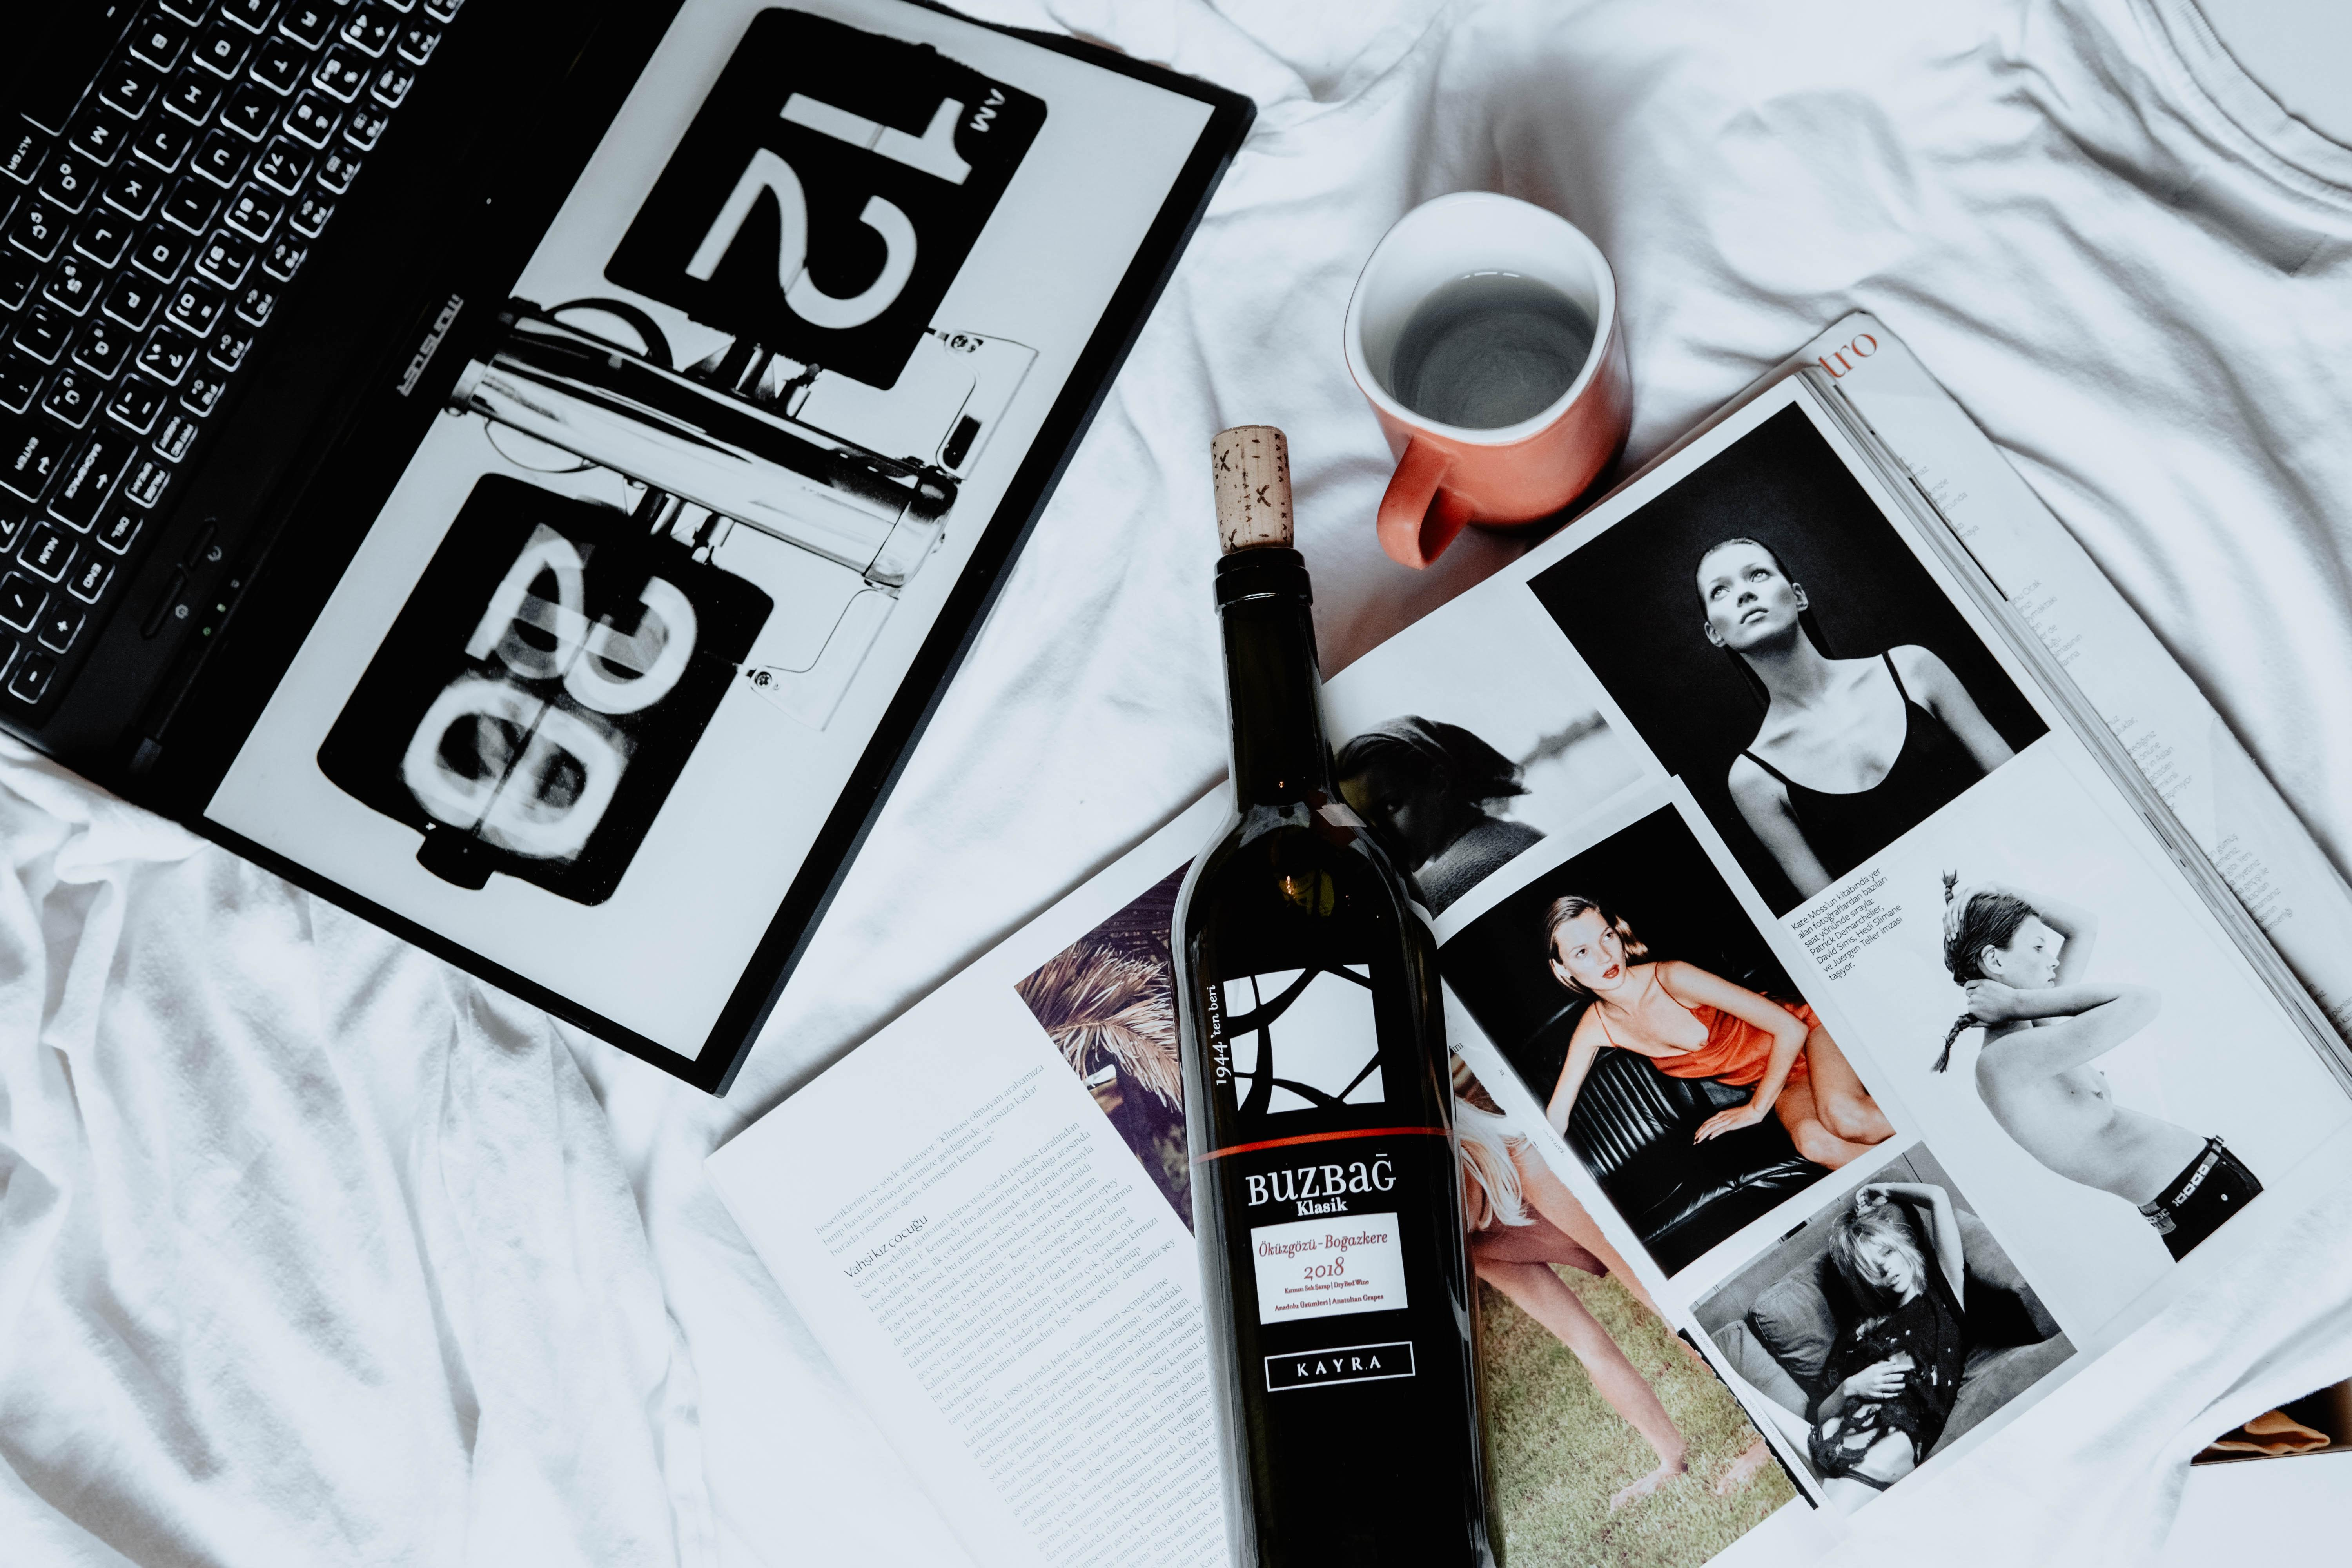

In [195]:
cropper = BottleCropper(model_path='./models/best_yolo26s.pt', bottle_class_id=0, conf_thresh=0.35)
image = os.listdir("./dataset/test/images/")[7]
display(IPyImage(os.path.join("./dataset/test/images/", image)))

INFO:BottleCropper:Вырезана самая большая бутылка: 'Wine_Botle', уверенность 73.54%, площадь 2419799 px²


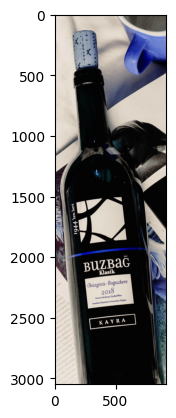

In [197]:
bottle = cropper.crop_image(os.path.join("./dataset/test/images/", image))
plt.imshow(bottle[0])

In [199]:
SYSTEM_PROMPT_OCR = (
    "Ты — высокоточный движок оптического распознавания символов (OCR). "
    "Твоя задача — извлекать структурированную информацию из этикетки вина "
    "Отвечай СТРОГО в формате валидного JSON. "
    "Ты должен извлекать ключевую информацию о вине: label: название вина - str, "
    "dry: количество сахара (сухое, полусухое, полусладкие, сладкое) - str, color: цвет (красное, розовое, белое) str, region: регион - str, "
    "grapes: сорта винограда - list[str], year: год изготовления - str. "
    "Не добавляй никаких пояснений до или после JSON. "
    "Не ставь метки формата данных. Только сам словарь "
    "Ты должен вставлять ключевую информация строго из текста"
    # "Твоя единственная задача — дословно, буква в букву, считывать весь видимый текст с изображения. "
    "СТРОГО ЗАПРЕЩЕНО: добавлять комментарии, исправлять ошибки, интерпретировать текст, "
    # "добавлять приветствия или пояснения. Выводи ТОЛЬКО сырой текст с картинки, "
    # "сохраняя оригинальный регистр, переносы строк и пунктуацию."
)

USER_PROMPT_OCR = "Буквально считай весь текст с этикетки этой бутылки. Возьми сорта винограда, регион, цыет вина, сухость вина, год."

In [201]:
ocr_raw = llm.generate(
    system_prompt=SYSTEM_PROMPT_OCR,
    user_prompt=USER_PROMPT_OCR,
    image_input=Image.fromarray(bottle[0])
)
ocr_raw

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


'{"label": "BUZBAĞ Klasik", "dry": "Kırmızı Bek Şarap | Dry Red Wine", "color": "красное", "region": "Anadolu Üzümleri | Anatolian Grapes", "grapes": ["Öküzgözü", "Boğazkere"], "year": "2018"}'

In [203]:
import json

data = json.loads(ocr_raw)
data

{'label': 'BUZBAĞ Klasik',
 'dry': 'Kırmızı Bek Şarap | Dry Red Wine',
 'color': 'красное',
 'region': 'Anadolu Üzümleri | Anatolian Grapes',
 'grapes': ['Öküzgözü', 'Boğazkere'],
 'year': '2018'}